Supervised Learing

In [36]:
## Simple linerar regression

Predicted Price: 123.63 Lakhs


c:\Users\User\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


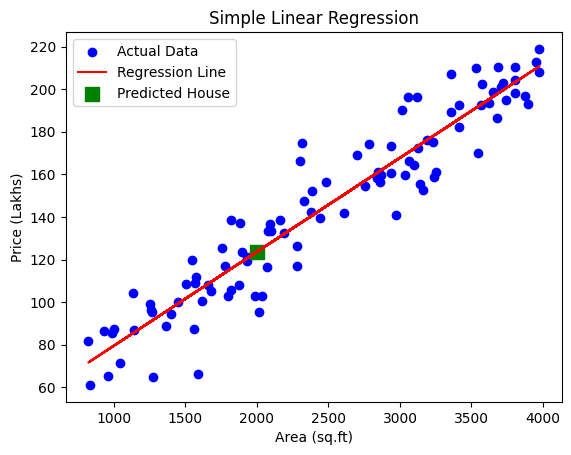

In [14]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

# Load dataset
df = pd.read_csv("HousePrice.csv")

# Feature and target
X = df[['Area']]
y = df['Price']

# Train model
model = LinearRegression()
model.fit(X, y)

# --- User Input with If-Else Validation ---
user_input = input("Enter the area in sq.ft to predict the price: ")

# Check if the input consists only of digits
if user_input.isdigit():
    user_area = float(user_input)
    
    # Predict price for user input
    pred = model.predict([[user_area]])
    print("Predicted Price:", round(pred[0], 2), "Lakhs")
    
    # --- Ask user if they want to plot the graph ---
    show_graph = input("\nDo you want to plot the graph? (yes/no): ").strip().lower()
    
    if show_graph == "yes":
        # Plot actual data
        plt.scatter(X, y, color='blue', label='Actual Data')

        # Regression line
        plt.plot(X, model.predict(X), color='red', label='Regression Line')

        # Predicted point
        plt.scatter(user_area, pred[0],
                    color='green',
                    marker='s',
                    s=100,
                    label='Predicted House')

        # Labels
        plt.xlabel("Area (sq.ft)")
        plt.ylabel("Price (Lakhs)")
        plt.title("Simple Linear Regression")
        plt.legend()

        plt.show()
    else:
        print("Graph skipped.")

else:
    print("Please enter the valid input.")

In [23]:
## Multi linerar regression

Predicted Price: 86.97 Lakhs


c:\Users\User\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
c:\Users\User\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


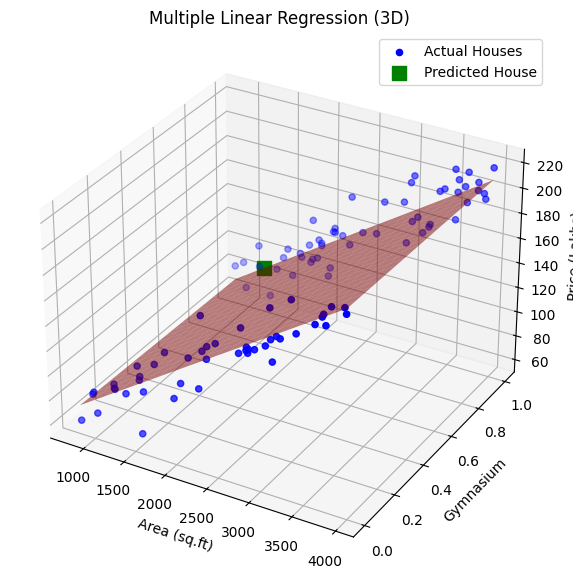

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from mpl_toolkits.mplot3d import Axes3D

# Load dataset
df = pd.read_csv("HousePrice.csv")

# Features and target
X = df[['Area', 'Gymnasium']]
y = df['Price']

# Train model
model = LinearRegression()
model.fit(X, y)

# --- User Input with If-Else Validation ---
area_input = input("Enter the area in sq.ft: ")
gym_input = input("Enter Gymnasium (1 for Yes, 0 for No): ")

# Check if both inputs consist only of digits
if area_input.isdigit() and gym_input.isdigit():
    user_area = float(area_input)
    user_gym = float(gym_input)
    
    # Predict for user input
    pred = model.predict([[user_area, user_gym]])
    print("Predicted Price:", round(pred[0], 2), "Lakhs")
    
    # --- Ask user if they want to plot the graph ---
    show_graph = input("\nDo you want to plot the 3D graph? (yes/no): ").strip().lower()
    
    if show_graph == "yes":
        # Create figure
        fig = plt.figure(figsize=(10,7))
        ax = fig.add_subplot(111, projection='3d')

        # Scatter plot of actual data
        ax.scatter(
            df['Area'],
            df['Gymnasium'],
            df['Price'],
            color='blue',
            label='Actual Houses'
        )

        # Create mesh grid for regression plane
        area_range = np.linspace(df['Area'].min(), df['Area'].max(), 20)
        gym_range = np.linspace(df['Gymnasium'].min(), df['Gymnasium'].max(), 20)

        Area_grid, Gym_grid = np.meshgrid(area_range, gym_range)

        # Predict prices for the grid
        Price_grid = model.predict(
            np.c_[Area_grid.ravel(), Gym_grid.ravel()]
        ).reshape(Area_grid.shape)

        # Plot regression plane
        ax.plot_surface(
            Area_grid,
            Gym_grid,
            Price_grid,
            alpha=0.5,
            color='red'
        )

        # Plot predicted point
        ax.scatter(
            user_area,
            user_gym,
            pred[0],
            color='green',
            marker='s',
            s=100,
            label='Predicted House'
        )

        # Labels
        ax.set_xlabel('Area (sq.ft)')
        ax.set_ylabel('Gymnasium')
        ax.set_zlabel('Price (Lakhs)')
        ax.set_title('Multiple Linear Regression (3D)')

        ax.legend()

        plt.show()
    else:
        print("Graph skipped.")

else:
    print("Please enter the valid input.")

In [33]:
## Logistic regression


========== RESULT ==========
Prediction : Disease
Probability of Disease     : 60.96%
Probability of No Disease  : 39.04%


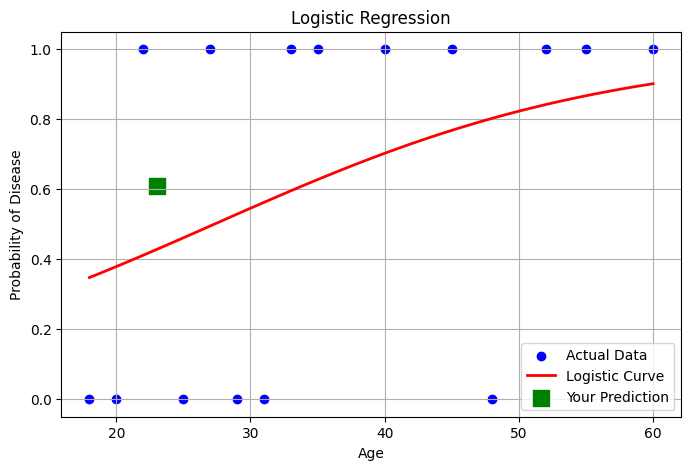

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression

# ---------------- Load Dataset ----------------
df = pd.read_csv("Disease_Prediction_Dataset.csv")

# Features and Target
X = df[['Age', 'Fever', 'Cough', 'Headache']]
y = df['Disease']

# ---------------- Train Model ----------------
model = LogisticRegression()
model.fit(X, y)

# ---------------- User Input ----------------
age = input("Enter Age: ")
fever = input("Do you have Fever? (1 = Yes, 0 = No): ")
cough = input("Do you have Cough? (1 = Yes, 0 = No): ")
headache = input("Do you have Headache? (1 = Yes, 0 = No): ")

# ---------------- Validation ----------------
if (age.isdigit() and
    fever in ["0", "1"] and
    cough in ["0", "1"] and
    headache in ["0", "1"]):

    age = int(age)
    fever = int(fever)
    cough = int(cough)
    headache = int(headache)

    # Create DataFrame (removes sklearn warning)
    user_data = pd.DataFrame({
        "Age": [age],
        "Fever": [fever],
        "Cough": [cough],
        "Headache": [headache]
    })

    # Prediction
    prediction = model.predict(user_data)
    probability = model.predict_proba(user_data)

    print("\n========== RESULT ==========")

    if prediction[0] == 1:
        print("Prediction : Disease")
    else:
        print("Prediction : No Disease")

    print(f"Probability of Disease     : {probability[0][1]*100:.2f}%")
    print(f"Probability of No Disease  : {probability[0][0]*100:.2f}%")

    # ---------------- Plot Graph ----------------
    show_graph = input("\nDo you want to plot the graph? (yes/no): ").strip().lower()

    if show_graph == "yes":

        plt.figure(figsize=(8,5))

        # Scatter plot of original data
        plt.scatter(df["Age"], df["Disease"],
                    color="blue",
                    label="Actual Data")

        # Logistic Curve
        age_range = np.linspace(df["Age"].min(),
                                df["Age"].max(),
                                100)

        curve_df = pd.DataFrame({
            "Age": age_range,
            "Fever": np.full(100, df["Fever"].mean()),
            "Cough": np.full(100, df["Cough"].mean()),
            "Headache": np.full(100, df["Headache"].mean())
        })

        y_prob = model.predict_proba(curve_df)[:,1]

        plt.plot(age_range,
                 y_prob,
                 color="red",
                 linewidth=2,
                 label="Logistic Curve")

        # User Prediction
        plt.scatter(age,
                    probability[0][1],
                    color="green",
                    marker="s",
                    s=120,
                    label="Your Prediction")

        plt.xlabel("Age")
        plt.ylabel("Probability of Disease")
        plt.title("Logistic Regression")
        plt.legend()
        plt.grid(True)

        plt.show()

    else:
        print("Graph skipped.")

else:
    print("\nPlease enter valid input.")

In [83]:
## K-means clustering


========== CLUSTER CENTERS ==========
[[8.2500e+05 4.6375e+01]
 [4.2500e+05 5.2375e+01]
 [1.2750e+06 5.1000e+01]]
----------------------------------------

========== RESULT ==========
Customer belongs to : Cluster 2
Customer Category : Regular Customer


c:\Users\User\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but KMeans was fitted with feature names
  warnings.warn(


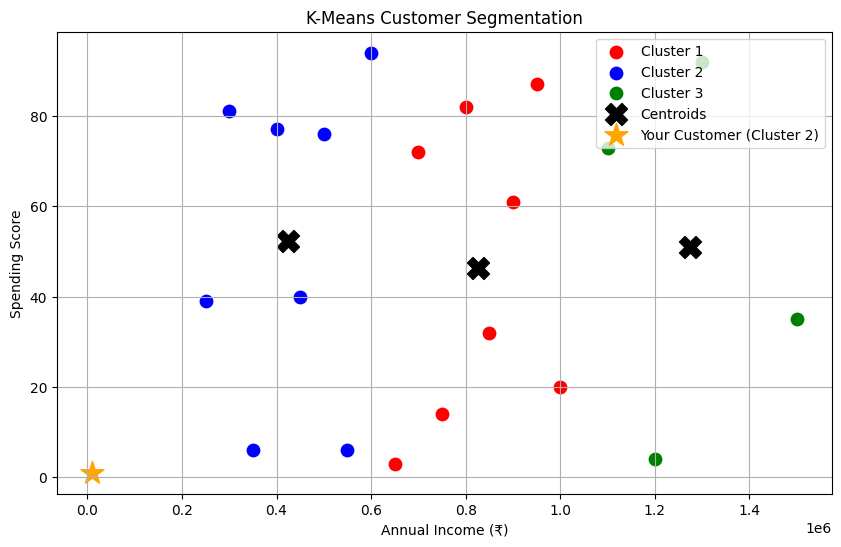

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

# ---------------- Load Dataset ----------------
df = pd.read_csv("Mall_Customer_Dataset_INR.csv")

# Features
X = df[['Annual_Income_INR', 'Spending_Score']]

# ---------------- Train K-Means Model ----------------
kmeans = KMeans(
    n_clusters=3,
    init='k-means++',
    random_state=42,
    n_init=10  #runs 10 times with different centroid seeds and returns the best output
)

df['Cluster'] = kmeans.fit_predict(X)

# Cluster Centers
centers = kmeans.cluster_centers_

print("\n========== CLUSTER CENTERS ==========")
print(centers)
print("-" * 40)

# ---------------- User Input ----------------
income_input = input("Enter Annual Income (₹): ")
score_input = input("Enter Spending Score (1-100): ")

# ---------------- Validation ----------------
if income_input.isdigit() and score_input.isdigit():

    income = int(income_input)
    score = int(score_input)

    # Predict Cluster
    user_cluster = kmeans.predict([[income, score]])[0]

    print("\n========== RESULT ==========")
    print(f"Customer belongs to : Cluster {user_cluster + 1}")

    # Category Names
    if user_cluster == 0:
        print("Customer Category : Budget Customer")
    elif user_cluster == 1:
        print("Customer Category : Regular Customer")
    else:
        print("Customer Category : Premium Customer")

    # ---------------- Ask for Graph ----------------
    show_graph = input("\nDo you want to plot the graph? (yes/no): ").strip().lower()

    if show_graph == "yes":

        plt.figure(figsize=(10,6))

        colors = ['red', 'blue', 'green']

        # Plot each cluster
        for i in range(3):
            cluster_data = df[df['Cluster'] == i]

            plt.scatter(
                cluster_data['Annual_Income_INR'],
                cluster_data['Spending_Score'],
                s=80,
                color=colors[i],
                label=f'Cluster {i+1}'
            )

        # Plot centroids
        plt.scatter(
            centers[:,0],
            centers[:,1],
            marker='X',
            s=250,
            color='black',
            label='Centroids'
        )

        # Plot user's point
        plt.scatter(
            income,
            score,
            color='orange',
            marker='*',
            s=300,
            label=f'Your Customer (Cluster {user_cluster+1})'
        )

        plt.title("K-Means Customer Segmentation")
        plt.xlabel("Annual Income (₹)")
        plt.ylabel("Spending Score")
        plt.legend()
        plt.grid(True)

        plt.show()

    else:
        print("Graph skipped.")

else:
    print("Please enter valid input.")

In [ ]:
## train-test split

In [100]:
import pandas as pd
from sklearn.model_selection import train_test_split

# Load dataset
df = pd.read_csv("HousePrice.csv")

# Features and target
X = df[['Area']]
y = df['Price']

print(f"Total rows in dataset: {len(df)}")
print("-" * 40)

# --- User Input with If-Else Validation ---
user_input = input("Enter test size percentage as a number (e.g., 20 for 20%, 30 for 30%): ").strip()

if user_input.isdigit():
    percent = int(user_input)
    
    # Validate that percentage is realistic (between 1 and 99)
    if 0 < percent < 100:
        # Convert integer percentage to a float ratio (e.g., 20 -> 0.2)
        test_ratio = percent / 100.0
        
        # Split data using the user's ratio
        X_train, X_test, y_train, y_test = train_test_split(
            X,
            y,
            test_size=test_ratio,
            random_state=42
        )

        # Display dynamic sizes based on their input
        print(f"\n--- Split Summary ({100 - percent}% Train / {percent}% Test) ---")
        print("Training Features Shape:", X_train.shape)
        print("Testing Features Shape:", X_test.shape)

        # --- Ask user if they want to inspect the split data ---
        show_data = input("\nDo you want to print the split sample frames? (yes/no): ").strip().lower()

        if show_data == "yes":
            print("\nTraining Data Subset (Top 5 Rows):")
            print(X_train.head())

            print("\nTesting Data Subset (Top 5 Rows):")
            print(X_test.head())
        else:
            print("Data preview skipped.")
            
    else:
        print("Please enter a valid percentage between 1 and 99.")
else:
    print("Please enter the valid input.")

Total rows in dataset: 100
----------------------------------------



--- Split Summary (80% Train / 20% Test) ---
Training Features Shape: (80, 1)
Testing Features Shape: (20, 1)

Training Data Subset (Top 5 Rows):
    Area
55  2861
88  1255
26  1259
42  1362
69  3053

Testing Data Subset (Top 5 Rows):
    Area
83  1001
53  1400
70  3952
45  3679
44  2067
